# Optimización Bayesiana
**Aprendizaje de Máquina - CEIA - FIUBA**

La idea central de la optimización bayesiana es aprender de evaluaciones previas para elegir el siguiente punto a probar.

Tiene dos componentes:
- un modelo probabilístico
- una función de adquisición

El algoritmo:
- Inicializa con X puntos (conjunto de hiperparámetros) aleatorios.
- Itera N veces: Explora y explota, evalúa la función objetivo y elige el mejor (o los mejores) parámetro(s) hasta el momento.
- Al final, devuelve la mejor combinación encontrada.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.interpolate import interp1d
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set()


In [2]:
# Dataset
pima_df = pd.read_csv("./datasets/pima_diabetes.csv")

# Los ceros se mantienen como 0: KNN los interpreta como señal
pima_df.head()


,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
X = pima_df.drop("diabetes", axis=1).values
y = pima_df["diabetes"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

print("Número de muestras:", X_train.shape[0])
print("Número de features:", X_train.shape[1])


Número de muestras: 576
Número de features: 8


---
## Búsqueda bayesiana 1-D (K de KNN)

- Función objetivo: buscamos maximizar la *exactitud balanceada*.
- Modelo probabilístico: usamos un proceso gaussiano (GP).
- Función de adquisición: elegimos *Expected Improvement* (EI).

#### Función objetivo

Es la que queremos maximizar. La función:
- recibe el hiperparámetro K
- crea un modelo KNN(k)
- calcula el score (el valor que queremos maximizar) como la **exactitud balanceada** promedio, usando validación cruzada 5-fold.

In [4]:
def knn_score_k(k):
    k = int(k)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    return np.mean(cross_val_score(model, X_train, y_train, cv=5, 
        scoring='balanced_accuracy'))


#### Modelo probabilístico

Optamos por un [Proceso Gaussiano (GP)](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)

In [5]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=5.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
    random_state=42)

#### Función de adquisición

Elegimos *Expected Improvement* (EI).

In [6]:
def expected_improvement(x_candidates, gp, y_best, xi=0.01):

    mu, sigma = gp.predict(x_candidates, return_std=True)
    mu = mu.ravel()
    sigma = sigma.ravel()
    sigma = np.maximum(sigma, 1e-9) # para evitar divisiones por cero

    improvement = mu - y_best - xi
    zz = improvement / sigma

    ei = improvement * norm.cdf(zz) + sigma * norm.pdf(zz)
    ei[sigma == 0.0] = 0.0
    return ei

#### Parámetros de búsqueda

In [7]:
K_range = np.arange(1, 51)          # dominio discreto
n_init = 5                          # puntos iniciales aleatorios
n_iter = 15                         # iteraciones del algoritmo

#### Puntos iniciales (exploración aleatoria)

- Se seleccionan n-init (5) valores aleatorios para los parámetros.
- Se evalúa la función objetivo (knn_score_k) en esos puntos.
- Estos son los primeros “puntos muestreados”, que sirven para construir un modelo inicial de la función objetivo.

In [8]:
rng = np.random.default_rng(42)
init_k = rng.choice(K_range, size=n_init, replace=False)
X_eval = np.array(init_k).reshape(-1,1).astype(float)
y_eval = np.array([knn_score_k(k) for k in init_k])

print(f'Valores iniciales elegidos para K: {init_k}')

Valores iniciales elegidos para K: [37 22 32  5 50]


#### Loop de optimización bayesiana

En cada iteración la búsqueda bayesiana 1D va ajustando el modelo probabilístico (GP) y eligiendo nuevos puntos según la función de adquisición (EI).

In [9]:
for it in range(n_iter):
    # entrenamos GP con lo observado hasta ahora
    gp.fit(X_eval, y_eval)

    # candidato = todos los K no evaluados aún
    candidates = np.array(K_range).reshape(-1, 1).astype(float)

    # calculamos EI para cada candidato
    y_best = y_eval.max()
    ei = expected_improvement(candidates, gp, y_best, xi=0.01)

    # excluimos candidatos ya evaluados
    evaluated_set = set(X_eval.ravel().astype(int).tolist())
    ei_masked = ei.copy()
    for i, k in enumerate(candidates.ravel().astype(int)):
        if k in evaluated_set:
            ei_masked[i] = -np.inf

    # elegimos el K con mayor EI
    next_idx = int(np.argmax(ei_masked))
    K_next = int(candidates[next_idx, 0])

    # evaluamos la función objetivo en K_next
    y_next = knn_score_k(K_next)

    # actualizamos datos
    X_eval = np.vstack([X_eval, [[K_next]]])
    y_eval = np.concatenate([y_eval, [y_next]])

    print(f"Iter {it+1:02d}: probando K={K_next} -> bal. accuracy={y_next:.4f} "
          f"(mejor hasta ahora = {y_eval.max():.4f})")

# Resultado final
best_idx = np.argmax(y_eval)
best_k = int(X_eval[best_idx, 0])
best_score = y_eval[best_idx]
print(f"\nMejor K encontrado (1D): {best_k} con exactitud balanceada: {best_score:.4f}")

Iter 01: probando K=41 -> bal. accuracy=0.6453 (mejor hasta ahora = 0.6664)
Iter 02: probando K=36 -> bal. accuracy=0.6608 (mejor hasta ahora = 0.6664)
Iter 03: probando K=38 -> bal. accuracy=0.6619 (mejor hasta ahora = 0.6664)
Iter 04: probando K=1 -> bal. accuracy=0.6804 (mejor hasta ahora = 0.6804)
Iter 05: probando K=2 -> bal. accuracy=0.5988 (mejor hasta ahora = 0.6804)
Iter 06: probando K=3 -> bal. accuracy=0.6931 (mejor hasta ahora = 0.6931)
Iter 07: probando K=4 -> bal. accuracy=0.6381 (mejor hasta ahora = 0.6931)
Iter 08: probando K=6 -> bal. accuracy=0.6235 (mejor hasta ahora = 0.6931)
Iter 09: probando K=7 -> bal. accuracy=0.6455 (mejor hasta ahora = 0.6931)
Iter 10: probando K=8 -> bal. accuracy=0.6206 (mejor hasta ahora = 0.6931)
Iter 11: probando K=9 -> bal. accuracy=0.6518 (mejor hasta ahora = 0.6931)
Iter 12: probando K=10 -> bal. accuracy=0.6500 (mejor hasta ahora = 0.6931)
Iter 13: probando K=11 -> bal. accuracy=0.6830 (mejor hasta ahora = 0.6931)
Iter 14: probando K=

### Visualización

**Panel superior — Modelo (GP)**

- Curva azul: predicción de la exactitud balanceada esperada (μ).
- Banda azul clara: incertidumbre del modelo (±1.96σ).
- Puntos magenta: valores realmente evaluados por cross-validation.
- Línea verde: mejor K observado.

**Panel inferior — Función de adquisición (EI)**
- Curva magenta: Expected Improvement (EI).

Picos altos de EI indican lugares prometedores para muestrear. Se busca un equilibrio entre alta predicción y alta incertidumbre.

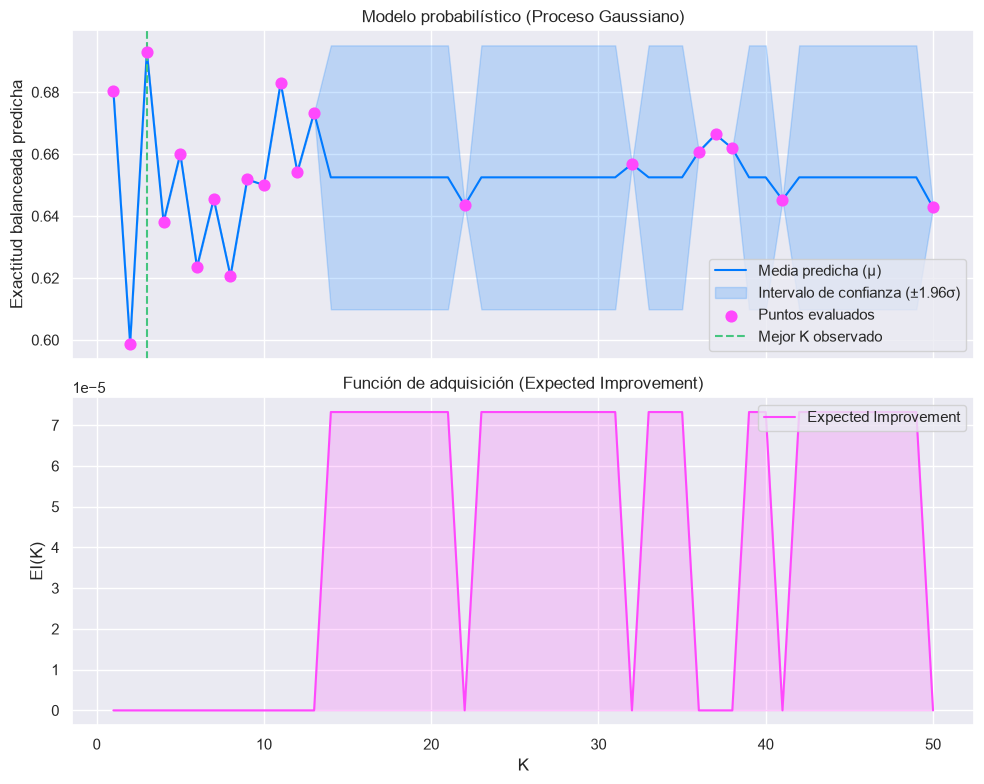

In [10]:
# Entrenamos el modelo final
gp.fit(X_eval, y_eval)
mu, sigma = gp.predict(K_range.reshape(-1, 1), return_std=True)
ei = expected_improvement(K_range.reshape(-1, 1), gp, y_eval.max(), xi=0.01)

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1) Modelo probabilístico (GP)
ax[0].plot(K_range, mu, color='#007aff', label='Media predicha (μ)')
ax[0].fill_between(K_range, mu - 1.96 * sigma, mu + 1.96 * sigma,
                   alpha=0.2, color='#007aff', label='Intervalo de confianza (±1.96σ)')
ax[0].scatter(X_eval, y_eval, color='#ff48fd', s=60, zorder=5, label='Puntos evaluados')
ax[0].axvline(X_eval[np.argmax(y_eval)], color='#44c57f', linestyle='--',
              label='Mejor K observado')
ax[0].set_ylabel("Exactitud balanceada predicha")
ax[0].set_title("Modelo probabilístico (Proceso Gaussiano)")
ax[0].legend(loc='lower right')

# 2) Función de adquisición (EI)
ax[1].plot(K_range, ei, color='#ff48fd', label='Expected Improvement')
ax[1].fill_between(K_range, 0, ei, color='#ff48fd', alpha=0.2)
ax[1].set_xlabel("K")
ax[1].set_ylabel("EI(K)")
ax[1].set_title("Función de adquisición (Expected Improvement)")
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## Búsqueda bayesiana para N parámetros

En este ejemplo vamos a buscar 3 parámetros:
- K (vecinos)
- pesos (uniforme o distancia)
- métrica (euclideana o manhattan)

Y definimos:
- Función objetivo: buscamos maximizar el *F1-score*.
- Modelo probabilístico: el mejor valor observado hasta ahora.
- Función de adquisición: seleccionar mejor + exploración ligera.


#### Hiperparámetros a optimizar

In [11]:
k_values = np.arange(1, 51)
weights_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

#### Función objetivo
- Recibe los hiperparámetros.
- Crea un modelo KNN con esos parámetros.
- Calcula el score (el valor que queremos maximizar) como el accuracy promedio, usando validación cruzada 5-fold.

In [12]:
def knn_score(params):
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(
            n_neighbors=int(params['K']),
            weights=params['weights'],
            metric=params['metric']
        ))
    ])
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    return np.mean(score)


#### Parámetros de búsqueda

In [13]:
n_init = 5     # puntos iniciales aleatorios
n_iter = 10    # iteraciones del algoritmo

#### Selección inicial de valores random (exploración)

- Se seleccionan n_init (5) valores aleatorios para los parámetros.
- Se evalúa la función objetivo (knn_score) en esos puntos.
- Estos son los primeros “puntos muestreados”, que sirven para construir un modelo inicial de la función objetivo.

In [14]:
# Lista para guardar resultados
evaluated_params = []
evaluated_scores = []

# Puntos iniciales (exploración)
np.random.seed(42)
for _ in range(n_init):  # puntos iniciales
    params = {
        'K': np.random.randint(1, 51),
        'weights': np.random.choice(weights_options),
        'metric': np.random.choice(metric_options)
    }
    score = knn_score(params)
    evaluated_params.append(params)
    evaluated_scores.append(score)

print('Valores iniciales elegidos para los hiper-parámetros:')
evaluated_params

Valores iniciales elegidos para los hiper-parámetros:


[{'K': 39, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')},
 {'K': 15, 'weights': np.str_('uniform'), 'metric': np.str_('manhattan')},
 {'K': 21, 'weights': np.str_('uniform'), 'metric': np.str_('manhattan')},
 {'K': 19, 'weights': np.str_('uniform'), 'metric': np.str_('euclidean')},
 {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')}]

#### Loop de optimización bayesiana

En cada iteración, la búsqueda va ajustando el modelo probabilístico y eligiendo nuevos puntos según la función de adquisición.

- Modelo: Es la lista de evaluaciones previas (evaluated_params y evaluated_scores) y la selección del mejor hasta ahora.
- Función de adquisición: decide dónde muestrear a continuación con una exploración ligera.

In [15]:
for i in range(n_iter):  # iteraciones
    
    # Elegimos el mejor parámetro hasta ahora (explotación)
    best_idx = np.argmax(evaluated_scores)
    best_params = evaluated_params[best_idx].copy()
    
    # Exploración ligera: modificamos un parámetro al azar
    param_to_change = np.random.choice(['K','weights','metric'])
    if param_to_change == 'K':
        best_params['K'] = np.random.randint(1, 51)
    elif param_to_change == 'weights':
        best_params['weights'] = np.random.choice(weights_options)
    else:
        best_params['metric'] = np.random.choice(metric_options)
    
    # Evaluamos nuevo conjunto
    score_new = knn_score(best_params)
    evaluated_params.append(best_params)
    evaluated_scores.append(score_new)
    
    print(f"Iteración {i+1}: {best_params} - F1-score={score_new:.4f}")

Iteración 1: {'K': 11, 'weights': np.str_('distance'), 'metric': np.str_('manhattan')} - F1-score=0.5292
Iteración 2: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5761
Iteración 3: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5761
Iteración 4: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5761
Iteración 5: {'K': 33, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5129
Iteración 6: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5761
Iteración 7: {'K': 44, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5050
Iteración 8: {'K': 49, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.4986
Iteración 9: {'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')} - F1-score=0.5761
Iteración 10: {'K': 2, 'weights': np.str_('distance'), 'metr

#### Resultado final

- Buscamos el mejor score entre todos los puntos evaluados.
- Mostramos el K que maximiza la accuracy según nuestra búsqueda simulada.

In [16]:
best_idx = np.argmax(evaluated_scores)
print("\nMejor combinación encontrada:")
print(evaluated_params[best_idx])
print("con F1-score:", evaluated_scores[best_idx])


Mejor combinación encontrada:
{'K': 2, 'weights': np.str_('distance'), 'metric': np.str_('euclidean')}
con F1-score: 0.5760898573271597


### Visualización

Todos los valores utilizados para los hiper-parámetros: K, pesos y métrica de distancia.

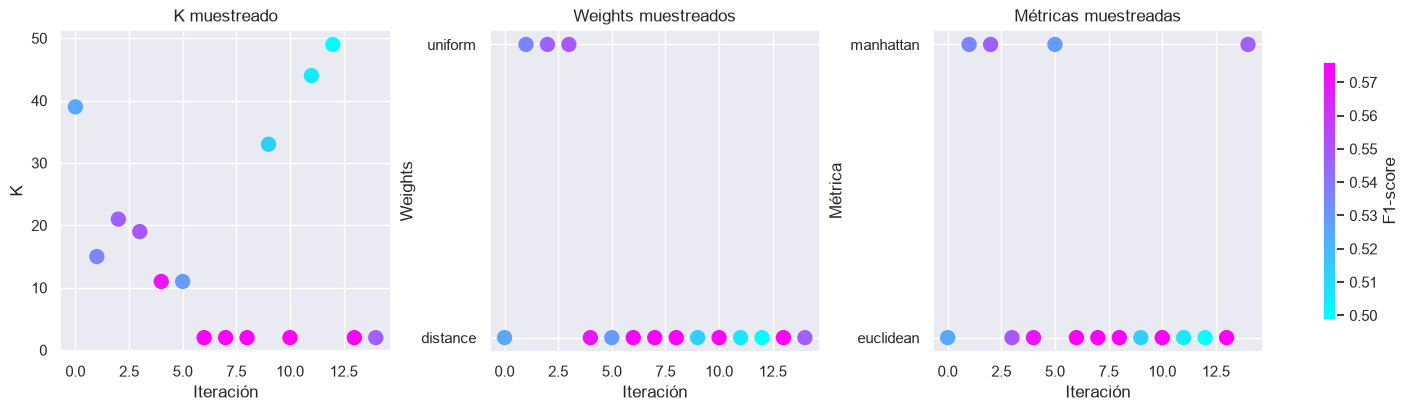

In [17]:
Ks = [p['K'] for p in evaluated_params]
weights = [p['weights'] for p in evaluated_params]
metrics = [p['metric'] for p in evaluated_params]

vmin, vmax = min(evaluated_scores), max(evaluated_scores)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, valores, titulo, ylabel in [
    (axes[0], Ks,      "K muestreado",        "K"),
    (axes[1], weights, "Weights muestreados",  "Weights"),
    (axes[2], metrics, "Métricas muestreadas", "Métrica"),
]:
    sc = ax.scatter(range(len(valores)), valores, c=evaluated_scores,
                    cmap='cool', s=100, vmin=vmin, vmax=vmax)
    ax.set_xlabel("Iteración")
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)

fig.colorbar(sc, ax=axes, label="F1-score", shrink=0.8)
plt.show()

### Visualización

Evolución del F1-score. Modelo. Puntos evaluados.

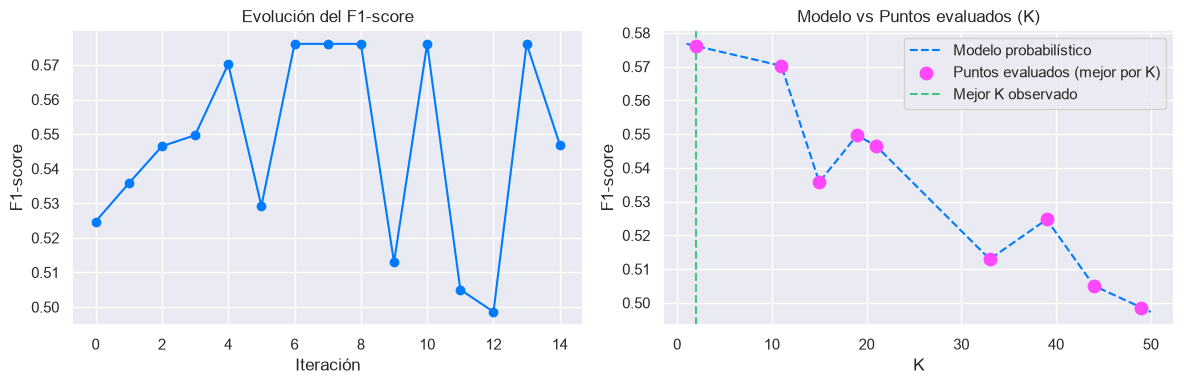

In [18]:
Ks = [p['K'] for p in evaluated_params]

# interp1d falla con x duplicados; nos quedamos con el mejor score por K único
k_best = {}
for k, s in zip(Ks, evaluated_scores):
    if k not in k_best or k_best[k] < s:
        k_best[k] = s
ks_unique   = sorted(k_best.keys())
scores_uniq = [k_best[k] for k in ks_unique]

K_range_interp = np.arange(1, 51)
model_interp = interp1d(ks_unique, scores_uniq, kind='linear', fill_value="extrapolate")
pred_scores = model_interp(K_range_interp)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Panel izquierdo: historia completa de evaluaciones (todos los intentos)
axs[0].plot(evaluated_scores, marker='o', color='#007aff')
axs[0].set_xlabel("Iteración")
axs[0].set_ylabel("F1-score")
axs[0].set_title("Evolución del F1-score")

# Panel derecho: modelo construido sobre K únicos + sus puntos de soporte
axs[1].plot(K_range_interp, pred_scores, '--', color='#007aff',
            label="Modelo probabilístico")
axs[1].scatter(ks_unique, scores_uniq, color='#ff48fd', s=80, zorder=5,
               label="Puntos evaluados (mejor por K)")
axs[1].axvline(evaluated_params[best_idx]['K'], color='#44c57f', linestyle='--',
               label='Mejor K observado')
axs[1].set_xlabel("K")
axs[1].set_ylabel("F1-score")
axs[1].set_title("Modelo vs Puntos evaluados (K)")
axs[1].legend()

plt.tight_layout()
plt.show()

### Entrenamiento y evaluación

In [19]:
best_params = evaluated_params[best_idx]

best_knn_bayesian = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        n_neighbors=int(best_params['K']),
        weights=best_params['weights'],
        metric=best_params['metric']
    ))
])
best_knn_bayesian.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


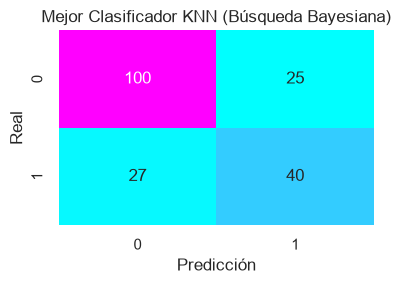

In [20]:
y_pred = best_knn_bayesian.predict(X_test)
cm_bayesian = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_bayesian, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax)
ax.set_title("Mejor Clasificador KNN (Búsqueda Bayesiana)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


In [21]:
TN, FP, FN, TP = cm_bayesian.ravel()

TPR = TP / (TP + FN)
TNR = TN / (TN + FP)

print("Mejor Clasificador KNN (Búsqueda Bayesiana)")
print(f"Sensibilidad (Recall): {TPR:.4f}")
print(f"Especificidad:         {TNR:.4f}")
print(f"Exactitud balanceada:  {(TPR + TNR) / 2:.4f}")
print(f"Precisión:             {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recuperación (Recall): {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score:              {f1_score(y_test, y_pred, zero_division=0):.4f}")


Mejor Clasificador KNN (Búsqueda Bayesiana)
Sensibilidad (Recall): 0.5970
Especificidad:         0.8000
Exactitud balanceada:  0.6985
Precisión:             0.6154
Recuperación (Recall): 0.5970
F1-score:              0.6061


---
## Comparativa final

Comparamos el mejor modelo encontrado por la búsqueda bayesiana contra el **baseline heurístico** de umbral de glucosa (el predictor más discriminativo según el EDA).

In [22]:
from sklearn.metrics import balanced_accuracy_score

# Baseline: umbral de glucosa
glucosa_sin_diabetes = pima_df.loc[pima_df["diabetes"] == 0, "glucosa"]
glucosa_con_diabetes = pima_df.loc[pima_df["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin_diabetes.median() + glucosa_con_diabetes.median()) / 2

print(f"Mediana glucosa — sin diabetes: {glucosa_sin_diabetes.median():.1f} mg/dL")
print(f"Mediana glucosa — con diabetes: {glucosa_con_diabetes.median():.1f} mg/dL")
print(f"Umbral elegido:                 {umbral_glucosa:.1f} mg/dL")

y_pred_baseline = (X_test[:, 1] > umbral_glucosa).astype(int)


Mediana glucosa — sin diabetes: 107.0 mg/dL
Mediana glucosa — con diabetes: 140.0 mg/dL
Umbral elegido:                 123.5 mg/dL


In [23]:
modelos = ["Baseline (umbral glucosa)", "KNN (Bayesiano)"]
preds   = [y_pred_baseline, y_pred]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp, zero_division=0) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Sensibilidad": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)


,F1-score,Exactitud balanceada,Precisión,Sensibilidad
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
KNN (Bayesiano),0.6061,0.6985,0.6154,0.5970


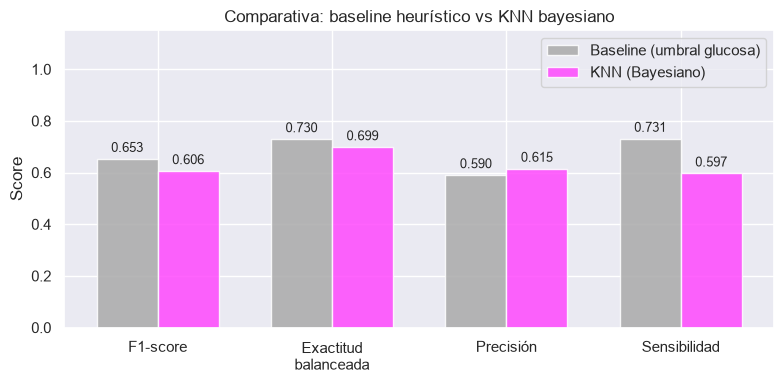

In [24]:
colores = ["#aaaaaa", "#ff48fd"]
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Sensibilidad"]
x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    bars = ax.bar(
        x + (i - 0.5) * width,
        df_cmp.iloc[i],
        width,
        label=modelo.replace("\n", " "),
        color=color,
        alpha=0.85,
    )
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa: baseline heurístico vs KNN bayesiano")
ax.legend()
plt.tight_layout()
plt.show()
